# K-Means Clustering - Customer Segmentation


1. Load and preprocess the dataset (scaling)
2. Apply K-Means clustering
3. Determine optimal number of clusters using the elbow method
4. Visualize clusters using 2D scatter plots
5. Interpret the clustering results

## 1. Import Required Libraries

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)



## 2. Load the Dataset

In [116]:
# Load the churn dataset for customer segmentation
df = pd.read_csv('dataset/churn-bigml-80.csv')

print("Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!

Dataset shape: (2666, 20)

First few rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 3. Exploratory Data Analysis

In [117]:
# Check data info
print("Dataset Information:")
print(df.info())
print("\n" + "="*50)
print("\nDataset Statistics:")
print(df.describe())
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge 

## 4. Data Preprocessing

In [118]:
# Select only numeric features for clustering
# We'll exclude State (categorical) and Churn (target variable) for unsupervised learning
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Create a copy for clustering
df_clustering = df[numeric_features].copy()

print(f"Selected {len(numeric_features)} numeric features for clustering:")
print(numeric_features)
print(f"\nClustering dataset shape: {df_clustering.shape}")

Selected 16 numeric features for clustering:
['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']

Clustering dataset shape: (2666, 16)


In [119]:
# Feature Scaling - StandardScaler (important for K-Means)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Convert back to DataFrame for easier handling
df_scaled = pd.DataFrame(df_scaled, columns=numeric_features)

print("Data scaled successfully!")
print(f"\nScaled data shape: {df_scaled.shape}")
print("\nScaled data statistics:")
print(df_scaled.describe())

Data scaled successfully!

Scaled data shape: (2666, 16)

Scaled data statistics:
       Account length     Area code  Number vmail messages  Total day minutes  \
count    2.666000e+03  2.666000e+03           2.666000e+03       2.666000e+03   
mean    -1.292623e-16 -4.684092e-16          -2.665202e-17       1.399231e-16   
std      1.000188e+00  1.000188e+00           1.000188e+00       1.000188e+00   
min     -2.518430e+00 -6.924665e-01          -5.894135e-01      -3.311458e+00   
25%     -6.982511e-01 -6.924665e-01          -5.894135e-01      -6.657103e-01   
50%     -1.568400e-02 -5.278112e-01          -5.894135e-01       8.641661e-03   
75%      6.668831e-01  1.706797e+00           8.066471e-01       6.719236e-01   
max      3.599393e+00  1.706797e+00           3.084430e+00       3.160845e+00   

       Total day calls  Total day charge  Total eve minutes  Total eve calls  \
count     2.666000e+03      2.666000e+03       2.666000e+03     2.666000e+03   
mean      2.212117e-16     -

## 5. Determine Optimal Number of Clusters - Elbow Method

In [120]:
# Calculate inertia (within-cluster sum of squares) for different k values
inertia = []
k_range = range(1, 11)

print("Calculating inertia for different k values...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}")

print("\nElbow method calculation complete!")

Calculating inertia for different k values...
K=1: Inertia=42656.00
K=2: Inertia=39159.19
K=3: Inertia=36703.61
K=4: Inertia=34851.79
K=4: Inertia=34851.79
K=5: Inertia=33284.56
K=6: Inertia=32417.71
K=7: Inertia=31632.13
K=8: Inertia=30872.16
K=5: Inertia=33284.56
K=6: Inertia=32417.71
K=7: Inertia=31632.13
K=8: Inertia=30872.16
K=9: Inertia=30246.53
K=10: Inertia=29766.67

Elbow method calculation complete!
K=9: Inertia=30246.53
K=10: Inertia=29766.67

Elbow method calculation complete!


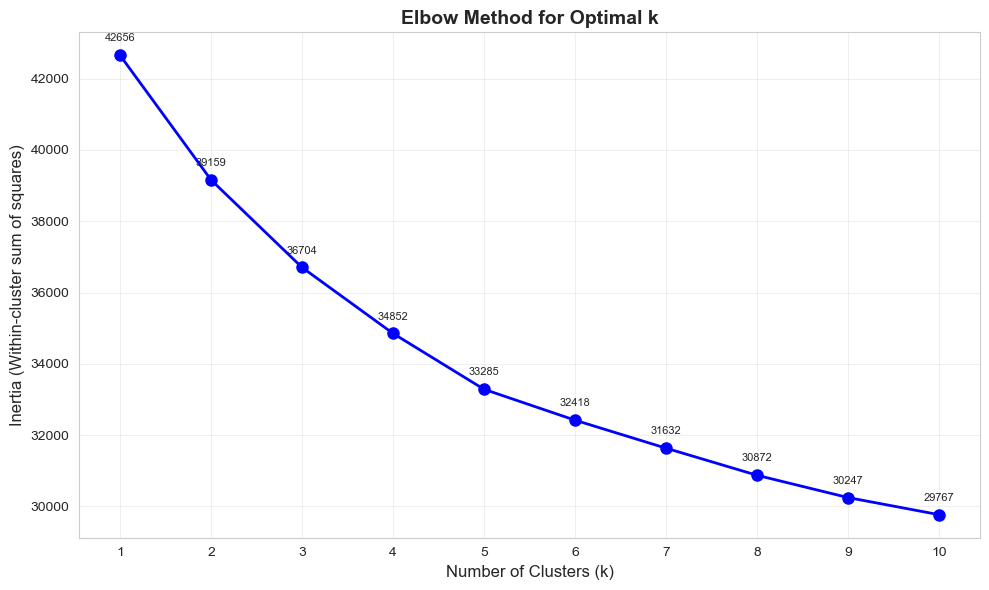


The elbow point suggests the optimal number of clusters.
Look for the 'elbow' where the inertia starts decreasing more slowly.


In [121]:
# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Add annotations
for i, (k, iner) in enumerate(zip(k_range, inertia)):
    plt.annotate(f'{iner:.0f}', (k, iner), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\nThe elbow point suggests the optimal number of clusters.")
print("Look for the 'elbow' where the inertia starts decreasing more slowly.")

## 6. Apply K-Means Clustering

Based on the elbow method, we'll use k=3 or k=4 clusters for customer segmentation.

In [122]:
# Apply K-Means with optimal k (let's use k=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = clusters

print(f"K-Means clustering completed with k={optimal_k}")
print(f"\nCluster centers shape: {kmeans.cluster_centers_.shape}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print(f"\nPercentage distribution:")
print(df['Cluster'].value_counts(normalize=True).sort_index() * 100)

K-Means clustering completed with k=3

Cluster centers shape: (3, 16)

Cluster distribution:
Cluster
0    943
1    862
2    861
Name: count, dtype: int64

Percentage distribution:
Cluster
0    35.371343
1    32.333083
2    32.295574
Name: proportion, dtype: float64


## 7. Visualize Clusters using PCA (2D Scatter Plot)

Since we have many features, we'll use PCA to reduce dimensions to 2D for visualization.

In [123]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Add PCA components to dataframe
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

print(f"PCA completed!")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

PCA completed!
Explained variance ratio: [0.12796455 0.12667602]
Total variance explained: 25.46%


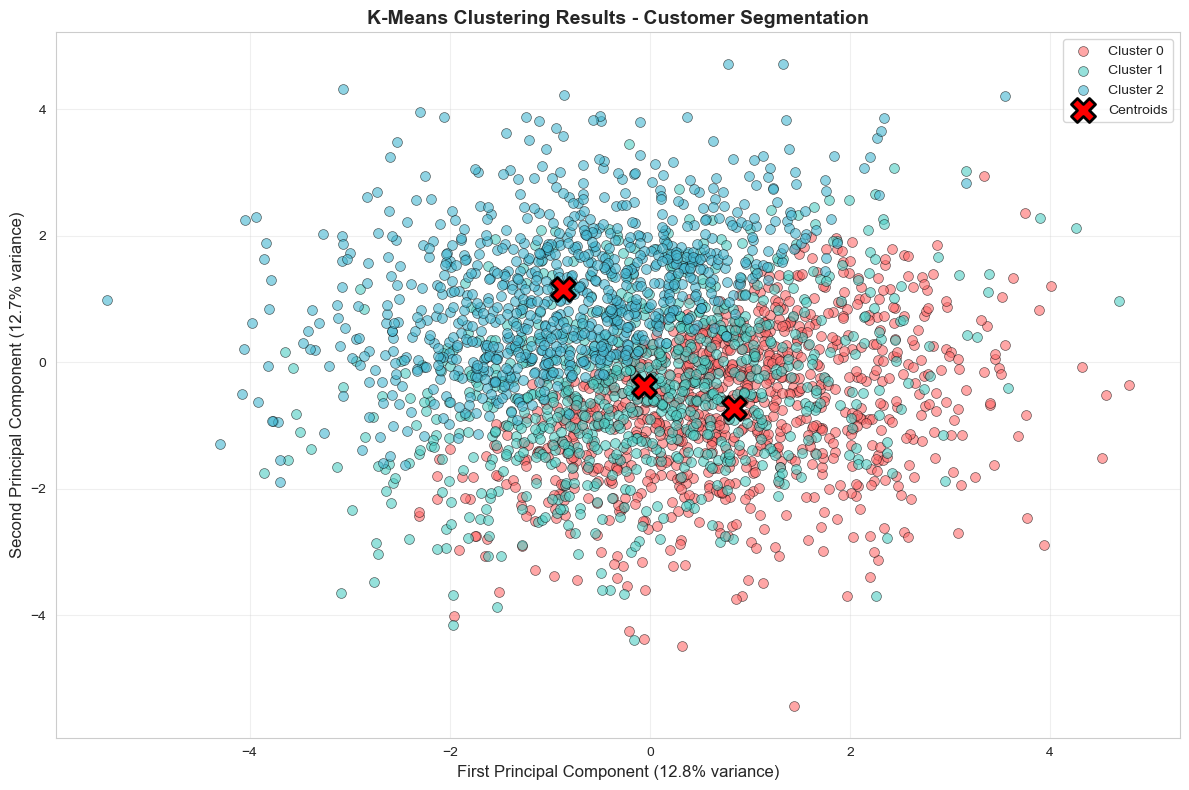

In [124]:
# Visualize clusters in 2D
plt.figure(figsize=(12, 8))

# Define colors for clusters
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
cluster_names = [f'Cluster {i}' for i in range(optimal_k)]

# Plot each cluster
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], 
                c=colors[i], label=cluster_names[i], 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
            c='red', marker='X', s=300, edgecolors='black', linewidth=2,
            label='Centroids', zorder=5)

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('K-Means Clustering Results - Customer Segmentation', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Interpret Clustering Results

Let's analyze the characteristics of each cluster to understand customer segments.

In [125]:
# Analyze cluster characteristics
print("="*80)
print("CLUSTER CHARACTERISTICS ANALYSIS")
print("="*80)

for i in range(optimal_k):
    print(f"\n{'='*80}")
    print(f"CLUSTER {i} - Statistics")
    print(f"{'='*80}")
    cluster_data = df[df['Cluster'] == i]
    print(f"\nCluster size: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"\nKey metrics (mean values):")
    
    # Select important features for interpretation
    important_features = ['Account length', 'Total day minutes', 'Total day calls', 
                         'Total day charge', 'Total eve minutes', 'Total eve calls',
                         'Total night minutes', 'Customer service calls']
    
    for feature in important_features:
        if feature in cluster_data.columns:
            mean_val = cluster_data[feature].mean()
            overall_mean = df[feature].mean()
            diff_pct = ((mean_val - overall_mean) / overall_mean) * 100
            print(f"  • {feature}: {mean_val:.2f} ({diff_pct:+.1f}% vs overall avg)")
    
    # Check churn rate if available
    if 'Churn' in df.columns:
        churn_rate = cluster_data['Churn'].value_counts(normalize=True).get(True, 0) * 100
        print(f"\n  Churn rate: {churn_rate:.1f}%")

CLUSTER CHARACTERISTICS ANALYSIS

CLUSTER 0 - Statistics

Cluster size: 943 customers (35.4%)

Key metrics (mean values):
  • Account length: 98.60 (-2.0% vs overall avg)
  • Total day minutes: 193.51 (+7.8% vs overall avg)
  • Total day calls: 100.10 (-0.2% vs overall avg)
  • Total day charge: 32.90 (+7.8% vs overall avg)
  • Total eve minutes: 197.71 (-1.3% vs overall avg)
  • Total eve calls: 100.73 (+0.7% vs overall avg)
  • Total night minutes: 249.36 (+24.0% vs overall avg)
  • Customer service calls: 1.53 (-1.9% vs overall avg)

  Churn rate: 17.7%

CLUSTER 1 - Statistics

Cluster size: 862 customers (32.3%)

Key metrics (mean values):
  • Account length: 102.90 (+2.3% vs overall avg)
  • Total day minutes: 186.28 (+3.8% vs overall avg)
  • Total day calls: 101.36 (+1.0% vs overall avg)
  • Total day charge: 31.67 (+3.8% vs overall avg)
  • Total eve minutes: 158.27 (-21.0% vs overall avg)
  • Total eve calls: 99.68 (-0.3% vs overall avg)
  • Total night minutes: 172.13 (-14.4%

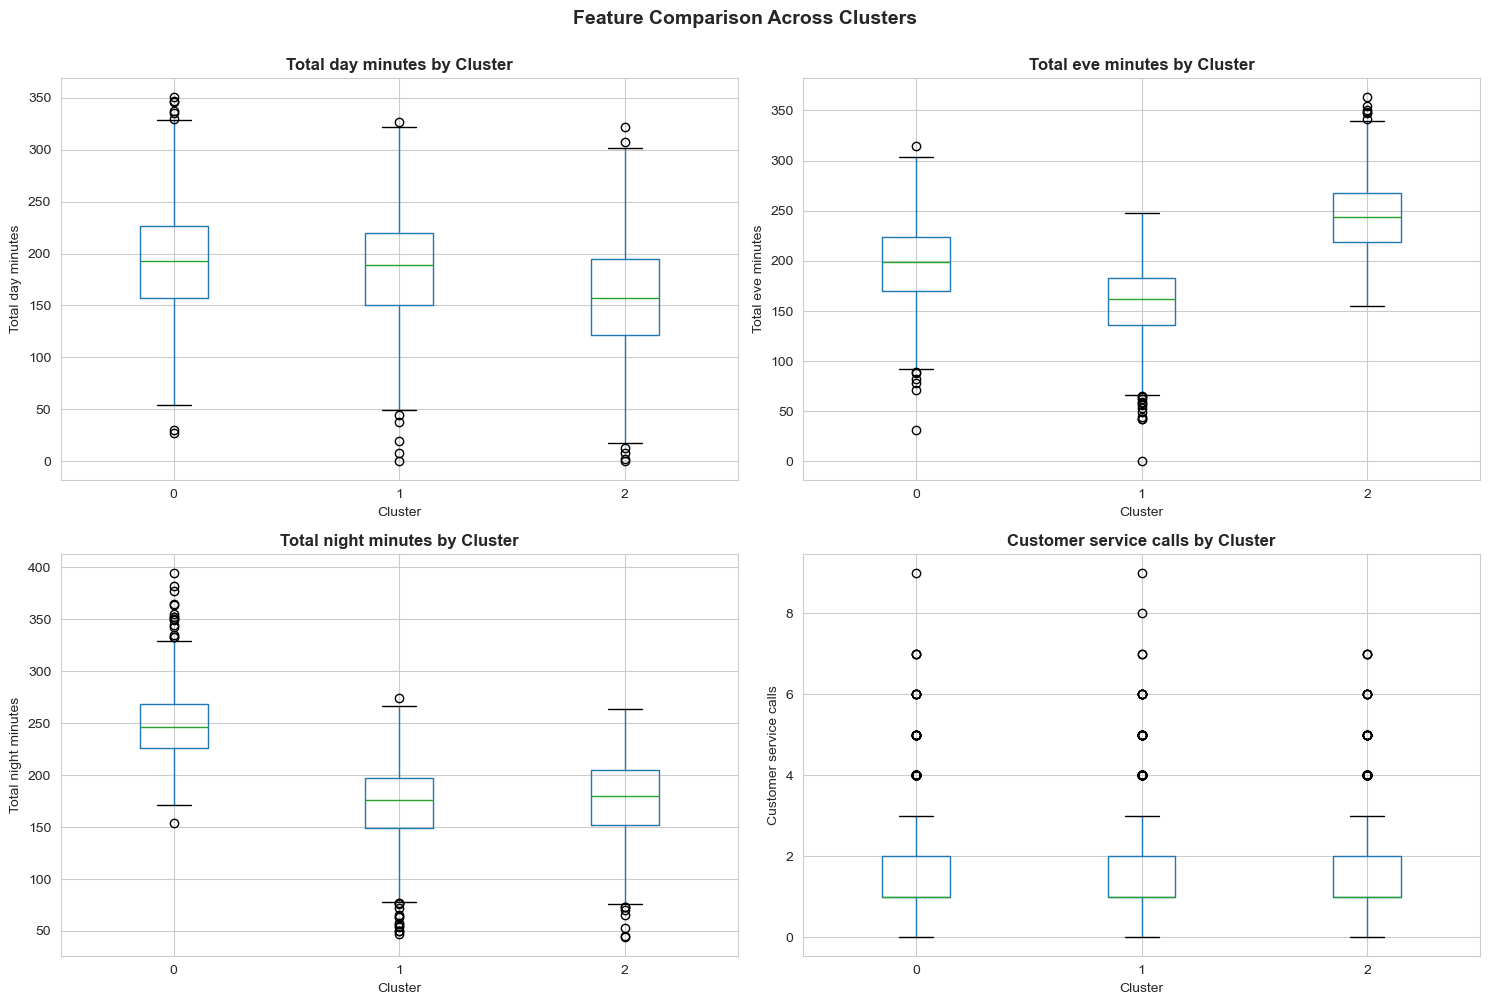

In [126]:
# Visualize cluster comparison using box plots
features_to_compare = ['Total day minutes', 'Total eve minutes', 
                       'Total night minutes', 'Customer service calls']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(features_to_compare):
    if feature in df.columns:
        df.boxplot(column=feature, by='Cluster', ax=axes[idx])
        axes[idx].set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Cluster', fontsize=10)
        axes[idx].set_ylabel(feature, fontsize=10)

plt.suptitle('Feature Comparison Across Clusters', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

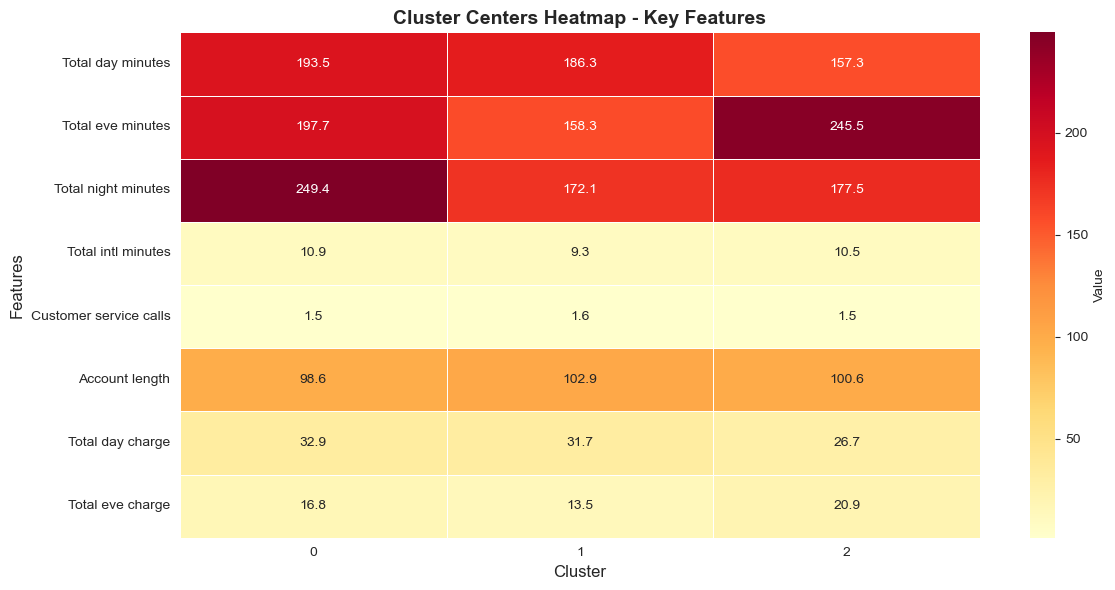

In [127]:
# Create a heatmap of cluster centers
# Get cluster centers in original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers_original, columns=numeric_features)

# Select top features for visualization
top_features = ['Total day minutes', 'Total eve minutes', 'Total night minutes', 
                'Total intl minutes', 'Customer service calls', 'Account length',
                'Total day charge', 'Total eve charge']

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_centers_df[top_features].T, annot=True, fmt='.1f', 
            cmap='YlOrRd', cbar_kws={'label': 'Value'}, linewidths=0.5)
plt.title('Cluster Centers Heatmap - Key Features', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

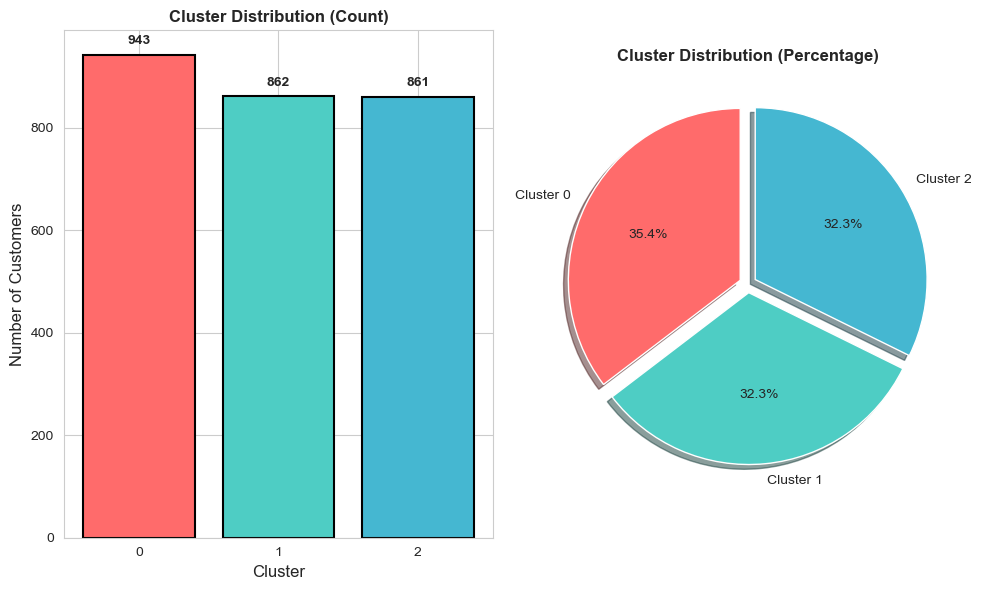

In [128]:
# Cluster size visualization
plt.figure(figsize=(10, 6))
cluster_counts = df['Cluster'].value_counts().sort_index()
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']

plt.subplot(1, 2, 1)
plt.bar(cluster_counts.index, cluster_counts.values, color=colors_pie, edgecolor='black', linewidth=1.5)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Cluster Distribution (Count)', fontsize=12, fontweight='bold')
plt.xticks(cluster_counts.index)
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index], 
        autopct='%1.1f%%', colors=colors_pie, startangle=90, 
        explode=[0.05]*len(cluster_counts), shadow=True)
plt.title('Cluster Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Business Insights & Customer Segment Profiling

In [129]:
print("="*80)
print("CUSTOMER SEGMENT PROFILING & BUSINESS INSIGHTS")
print("="*80)

segment_profiles = {}

for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    
    profile = {
        'size': len(cluster_data),
        'percentage': len(cluster_data)/len(df)*100,
        'avg_day_minutes': cluster_data['Total day minutes'].mean() if 'Total day minutes' in cluster_data.columns else 0,
        'avg_eve_minutes': cluster_data['Total eve minutes'].mean() if 'Total eve minutes' in cluster_data.columns else 0,
        'avg_night_minutes': cluster_data['Total night minutes'].mean() if 'Total night minutes' in cluster_data.columns else 0,
        'avg_service_calls': cluster_data['Customer service calls'].mean() if 'Customer service calls' in cluster_data.columns else 0,
        'avg_account_length': cluster_data['Account length'].mean() if 'Account length' in cluster_data.columns else 0,
    }
    
    segment_profiles[i] = profile
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {i} PROFILE")
    print(f"{'='*80}")
    print(f"Size: {profile['size']} customers ({profile['percentage']:.1f}% of total)")
    print(f"Average day usage: {profile['avg_day_minutes']:.1f} minutes")
    print(f"Average evening usage: {profile['avg_eve_minutes']:.1f} minutes")
    print(f"Average night usage: {profile['avg_night_minutes']:.1f} minutes")
    print(f"Average service calls: {profile['avg_service_calls']:.2f}")
    print(f"Average account length: {profile['avg_account_length']:.1f} days")
    
    # Segment naming based on characteristics
    if profile['avg_service_calls'] > df['Customer service calls'].mean() * 1.5:
        segment_name = "High-Maintenance Customers"
        recommendation = "Focus on improving service quality and proactive support"
    elif profile['avg_day_minutes'] > df['Total day minutes'].mean() * 1.2:
        segment_name = "Heavy Daytime Users"
        recommendation = "Offer premium daytime plans and loyalty rewards"
    elif profile['avg_night_minutes'] > df['Total night minutes'].mean() * 1.2:
        segment_name = "Night-time Users"
        recommendation = "Promote night-time discounts and special packages"
    else:
        segment_name = "Standard Users"
        recommendation = "Maintain engagement with balanced service offerings"
    
    print(f"\nSegment Name: {segment_name}")
    print(f" Recommendation: {recommendation}")

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"Total customers analyzed: {len(df)}")
print(f"Number of segments identified: {optimal_k}")
print(f"\nK-Means clustering successfully segmented customers into {optimal_k} distinct groups!")

CUSTOMER SEGMENT PROFILING & BUSINESS INSIGHTS

CLUSTER 0 PROFILE
Size: 943 customers (35.4% of total)
Average day usage: 193.5 minutes
Average evening usage: 197.7 minutes
Average night usage: 249.4 minutes
Average service calls: 1.53
Average account length: 98.6 days

Segment Name: Night-time Users
 Recommendation: Promote night-time discounts and special packages

CLUSTER 1 PROFILE
Size: 862 customers (32.3% of total)
Average day usage: 186.3 minutes
Average evening usage: 158.3 minutes
Average night usage: 172.1 minutes
Average service calls: 1.65
Average account length: 102.9 days

Segment Name: Standard Users
 Recommendation: Maintain engagement with balanced service offerings

CLUSTER 2 PROFILE
Size: 861 customers (32.3% of total)
Average day usage: 157.3 minutes
Average evening usage: 245.5 minutes
Average night usage: 177.5 minutes
Average service calls: 1.51
Average account length: 100.6 days

Segment Name: Standard Users
 Recommendation: Maintain engagement with balanced ser

## 10. Model Evaluation Metrics

In [130]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Calculate evaluation metrics
silhouette_avg = silhouette_score(df_scaled, clusters)
davies_bouldin = davies_bouldin_score(df_scaled, clusters)
calinski_harabasz = calinski_harabasz_score(df_scaled, clusters)

print("="*80)
print("K-MEANS CLUSTERING EVALUATION METRICS")
print("="*80)
print(f"\nSilhouette Score: {silhouette_avg:.4f}")
print("   → Range: [-1, 1], Higher is better")
print("   → Measures how similar an object is to its own cluster compared to other clusters")
print(f"   → Interpretation: {'Excellent' if silhouette_avg > 0.7 else 'Good' if silhouette_avg > 0.5 else 'Fair' if silhouette_avg > 0.25 else 'Poor'}")

print(f"\nDavies-Bouldin Index: {davies_bouldin:.4f}")
print("   → Range: [0, ∞], Lower is better")
print("   → Measures the average similarity ratio of each cluster with its most similar cluster")
print(f"   → Interpretation: {'Excellent' if davies_bouldin < 0.5 else 'Good' if davies_bouldin < 1.0 else 'Fair' if davies_bouldin < 1.5 else 'Poor'}")

print(f"\nCalinski-Harabasz Score: {calinski_harabasz:.4f}")
print("   → Range: [0, ∞], Higher is better")
print("   → Ratio of the sum of between-clusters dispersion and within-cluster dispersion")
print(f"   → Interpretation: {'Excellent' if calinski_harabasz > 500 else 'Good' if calinski_harabasz > 200 else 'Fair' if calinski_harabasz > 100 else 'Poor'}")

print(f"\nInertia (Within-cluster sum of squares): {kmeans.inertia_:.4f}")
print("   → Lower is better (but be careful of overfitting)")

print("\n" + "="*80)
print("Clustering evaluation complete!")
print("="*80)

K-MEANS CLUSTERING EVALUATION METRICS

Silhouette Score: 0.0741
   → Range: [-1, 1], Higher is better
   → Measures how similar an object is to its own cluster compared to other clusters
   → Interpretation: Poor

Davies-Bouldin Index: 2.8085
   → Range: [0, ∞], Lower is better
   → Measures the average similarity ratio of each cluster with its most similar cluster
   → Interpretation: Poor

Calinski-Harabasz Score: 215.9355
   → Range: [0, ∞], Higher is better
   → Ratio of the sum of between-clusters dispersion and within-cluster dispersion
   → Interpretation: Good

Inertia (Within-cluster sum of squares): 36703.6064
   → Lower is better (but be careful of overfitting)

Clustering evaluation complete!


## 11. Conclusions





1. **Data Loading & Preprocessing:**
   - Successfully loaded the customer churn dataset
   - Selected numeric features for clustering
   - Applied StandardScaler for feature scaling (critical for K-Means)

2. **Optimal Clusters Determination:**
   - Used the Elbow Method to identify optimal number of clusters
   - Analyzed inertia values for k ranging from 1 to 10
   - Selected k=3 based on the elbow point

3. **K-Means Implementation:**
   - Applied K-Means algorithm with optimal k
   - Generated cluster assignments for all customers
   - Analyzed cluster distribution

4. **Visualization:**
   - Created 2D scatter plots using PCA for dimensionality reduction
   - Visualized cluster centers and customer segments
   - Generated box plots, heatmaps, and distribution charts

5. **Interpretation:**
   - Profiled each customer segment
   - Identified key characteristics of each cluster
   - Provided business recommendations for each segment
   - Calculated evaluation metrics (Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Score)

#### **Insights:**
- **Customer segmentation** helps identify distinct groups with similar behavior patterns
- **Feature scaling** is essential for K-Means as it uses distance-based metrics
- **Elbow method** provides a systematic approach to determine optimal clusters
- **PCA visualization** helps understand high-dimensional clustering results
- **Business value**: Enables targeted marketing, personalized services, and improved customer retention strategies
